# Cross Sectional Momentum Portfolio 
### By Danny Salib 

### Getting Started

In [2]:
from pathlib import Path
import pickle as pkl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from tqdm import tqdm
from scipy.stats import zscore


from csm.config import Config, Param
from csm.state import State, cached_on_state
from csm.universe import Universe
from csm.signals import Signal, PortfolioBuilder
from csm.data import download_data
from csm.backtest import build_signal, compute_backtest_returns
from csm.risk import compute_volatility_managed_returns
from csm.performance import compute_performance_stats, log_performance_table
from csm.plotting import plot_perf

In [3]:
plt.style.use('classic')
plt.rcParams['lines.linewidth'] = 1.5

### Creating configuration and state machine 

In [4]:
# TODO explain what you mean here

In [5]:
cfg = Config()
state = State()

### Stock Selection Aalysis

##### Universe implementation 
At first I was using the SP500 stocks as my universe, but I want to take a more academic approach. The problem is, academics don't care about tradeable stocks, and care more about broad stroke anomlies that may exist in the world. To bridge this gap, I'll swap the SP500 stocks for a larger universe: NASDAQ

In [6]:
# TODO talk about this

In [7]:
class NasdaqUniverse(Universe):
    def load(cfg) -> list[str]:
        # Get NASDAQ stocks
        df = pd.read_csv("https://www.nasdaqtrader.com/dynamic/symdir/nasdaqlisted.txt", sep="|")[:-1]
        # drop test issues
        df = df[df['Test Issue'] == 'N']
        # drop ETFs if you only want single-name equities
        df = df[df['ETF'] == 'N']
        df = df.dropna(subset=['Symbol'])
        # drop obvious non-common-stock structures via name pattern
        junk_pattern = r'Warrant|Unit|Right|Preferred|Depositary|Acquisition Corp|SPAC|Trust'
        df = df[~df['Security Name'].str.contains(junk_pattern, case=False, na=False)]

        # Filter out tickers
        tickers  = df['Symbol'].tolist()
        batches  = [tickers[i:i+200] for i in range(0, len(tickers), 200)]
        snapshot = []
        for batch in batches:
            data = yf.download(batch, period="5d", group_by="ticker", threads=True)
            for t in batch:
                try:
                    close = data[t]['Close'].iloc[-1]
                    vol = data[t]['Volume'].mean()
                    snapshot.append({'ticker': t, 'price': close, 'avg_vol': vol})
                except Exception:
                    continue
        snap_df = pd.DataFrame(snapshot).dropna()
        snap_df['dollar_vol'] = snap_df['price'] * snap_df['avg_vol']
        snap_df  = snap_df[snap_df['price'] > 5]
        snap_df  = snap_df.sort_values('dollar_vol', ascending=False)
        n_stocks = getattr(cfg, 'nasdaq_n_stocks', 2_000)
        return snap_df.head(n_stocks)['ticker'].tolist()

In [8]:
USE_CACHED_TICKERS: bool = True
TICKERS_CACHE_PATH: Path = Path('./.cache/ticker.pkl')

if USE_CACHED_TICKERS and TICKERS_CACHE_PATH.exists():
    with open(TICKERS_CACHE_PATH, 'rb') as f: state.tickers = pkl.load(f)
else:
    state.tickers = NasdaqUniverse.load(cfg)
    with open(TICKERS_CACHE_PATH, 'wb') as f: pkl.dump(state.tickers, f)

# state.tickers

### Downloading Data

In [9]:
# TODO explain what download_data is doing cuz it's pretty cool

In [10]:
@cached_on_state('data')
def get_data(cfg, state):
    return download_data(cfg, state.tickers)

get_data(cfg, state).tail()
# state.data.tail()

Price       Close                                                           \
Ticker       AACB        AAL        AAOI       AAON       AAPG        AAPL   
Date                                                                         
2026-07-30  10.53  15.430000   90.110001  87.589996  18.070000  333.429993   
2026-07-31  10.53  15.270000   94.320000  89.059998  17.424999  308.910004   
2026-08-03  10.54  16.040001  110.209999  92.559998  16.805000  303.420013   
2026-08-04  10.54  16.559999  131.630005  95.550003  16.690001  309.380005   
2026-08-05  10.56  16.580000  128.559998  93.150002  16.855000  311.000000   

Price                                     ...   Volume                      \
Ticker      AARD  ABCL  ABEO        ABNB  ...       ZG     ZION         ZM   
Date                                      ...                                
2026-07-30  6.40  5.69  6.47  152.080002  ...  1630800  1265600  2840600.0   
2026-07-31  6.60  5.71  6.42  151.520004  ...  2936900  1195400  4598800.0   
2026-08-03  7.08  5.83  6.39  150.639999  ...  1183200  2231200  3355000.0   
2026-08-04  7.23  6.09  6.82  149.919998  ...  1142000  1975400  3653500.0   
2026-08-05  7.52  5.92  6.80  152.490005  ...  1398500  1459900  2557100.0   

Price                                                                           
Ticker         ZOOZ         ZS        ZTG    ZUMZ      ZURA     ZVRA      ZYME  
Date                                                                            
2026-07-30  11900.0  2879300.0  1041500.0  182500  409700.0  1912600  402900.0  
2026-07-31   5600.0  2648100.0   896200.0  190100  541100.0   971100  375100.0  
2026-08-03   3500.0  2657200.0   893200.0  180000  435200.0  1753700  398300.0  
2026-08-04   2400.0  2516200.0  1781600.0  232900  702700.0  1284500  419800.0  
2026-08-05   9000.0  1955200.0  1591600.0  720100  852100.0   776900  488400.0  

[5 rows x 9460 columns]

In [11]:
@cached_on_state('benchmark')
def get_benchmark(cfg, state, **kwargs):
    t = getattr(cfg, 'benchmark_ticker', 'SPY')
    return download_data(cfg, [t]).Close.iloc[:, 0]

In [12]:
@cached_on_state('rf_daily')
def get_rf_daily(cfg, state, **kwargs):
    rf_annual_rate = download_data(cfg, ['^IRX']).Close.iloc[:, 0] / 100
    return (1 + rf_annual_rate) ** (1/252) - 1

### Creating Signals for DUAL Momentum

In [ ]:
# TODO remove hindsight bias via skip days
def absMom(cfg, data: pd.DataFrame | pd.Series):
    skip = getattr(cfg, 'skip_days', 5) # Gary Antonacci reccomends 5 over 21
    lb = getattr(cfg, 'abs_mom_lb', 252)
    stock_prices = data.shift(skip)
    return (stock_prices / stock_prices.shift(lb)) - 1

class AbsMomInd(Signal):
    @staticmethod
    @cached_on_state('data_absolute_momentum')
    def signal(cfg, state) -> pd.DataFrame:
        rf_daily = get_rf_daily(cfg, state)
        skip = getattr(cfg, 'skip', 21)
        lb = getattr(cfg, 'risk_free_lb', 21)
        rf_return = (
            (1 + rf_daily)
            .shift(skip)
            .rolling(lb)
            .apply(np.prod, raw=True)
            .sub(1)
        )
        return absMom(cfg, state.data.Close).sub(rf_return, axis=0)

# TODO relative to their category not benchmark
class RelMomInd(Signal):
    @staticmethod
    @cached_on_state('data_relative_momentum')
    def signal(cfg, state) -> pd.DataFrame:
        bm_mom = absMom(cfg, get_benchmark(cfg, state))
        return AbsMomInd.signal(cfg, state).sub(bm_mom, axis=0)

class DualMomInd(Signal):
    @staticmethod
    @cached_on_state('data_dual_momentum')
    def signal(cfg, state) -> pd.DataFrame:
        abs_mom = AbsMomInd.signal(cfg, state)
        rel_mom = RelMomInd.signal(cfg, state)
        return rel_mom * abs_mom.gt(0).astype(float)

# this sucks
class SpySmaMrf(Signal):
    @staticmethod
    @cached_on_state('mrf')
    def signal(cfg, state):
        lb = getattr(cfg, 'spy_sma_lb', 252)
        return state.benchmark <= state.benchmark.rolling(lb).mean()

@cached_on_state('universe_return')
def get_universe_return(cfg, state, **kwargs):
    if not hasattr(state, 'data'): raise RuntimeError('No Data') # TODO vague
    return state.data.Close.pct_change()

class InvVolSig(Signal):
    @staticmethod
    @cached_on_state('inverse_volatility')
    def signal(cfg, state):
        lb = getattr(cfg, 'inverse_volatility_lookback', 21)
        u_ret = get_universe_return(cfg, state)
        vol = u_ret.rolling(lb).std().shift(1)
        return 1 / vol.replace(0, np.nan)

class FrogInPan(Signal):
    @staticmethod
    @cached_on_state("frog_in_pan")
    def signal(cfg, state):
        u_ret = get_universe_return(cfg, state)
        lb = getattr(cfg, "frog_in_pan_lb", 21)
        pos = u_ret.gt(0).rolling(lb).mean()
        neg = u_ret.lt(0).rolling(lb).mean()
        cum_ret = u_ret.rolling(lb).apply(
            lambda x: np.prod(1 + x) - 1,
            raw=True,
        )
        return -np.sign(cum_ret) * (neg - pos)


### Building the Signal 

In [14]:
class CsmPortfolioBuilder(PortfolioBuilder):
    @staticmethod
    def build_signal(cfg: Config, state: State) -> pd.DataFrame:
        signal_df = PortfolioBuilder._make_signal_df(cfg, state)
        dm_df = DualMomInd.signal(cfg, state)
        iv_df = InvVolSig.signal(cfg, state)
        fip_df = FrogInPan.signal(cfg, state)
        # mrf = SpySmaMrf.signal(cfg, state)

        n_basket = getattr(cfg, 'n_basket', 100)
        for d in tqdm(signal_df.index):
            # if mrf.loc[d]: continue

            winner_df = dm_df.loc[d][lambda x: x.gt(0)].to_frame('dm')
            if winner_df.empty: continue

            winner_df['fip'] = fip_df.loc[d, winner_df.index]
            winner_df = winner_df.dropna()
            if winner_df.empty: continue

            winner_df = winner_df.apply(zscore)
            winner_df['score'] = winner_df.sum(axis=1)
            winners = winner_df.nlargest(n_basket, 'score').index

            weight = iv_df.loc[d, winners] / iv_df.loc[d, winners].sum()
            signal_df.loc[d, winners] = weight
        return signal_df

In [15]:
@cached_on_state('signal_df')
def create_signal_df(cfg, state, portfolio_builder: PortfolioBuilder | None = None, **kwargs):
    if portfolio_builder is None:
        raise RuntimeError("No portfolio builder and no signal DataFrame.")
    return portfolio_builder.build_signal(cfg=cfg, state=state)

create_signal_df(cfg, state, portfolio_builder=CsmPortfolioBuilder).tail()

C:\Users\Danny\AppData\Local\Temp\ipykernel_13832\856908.py:51: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return state.data.Close.pct_change()
100%|██████████| 523/523 [00:02<00:00, 228.15it/s]


Ticker,AACB,AAL,AAOI,AAON,AAPG,AAPL,AARD,ABCL,ABEO,ABNB,...,ZG,ZION,ZM,ZOOZ,ZS,ZTG,ZUMZ,ZURA,ZVRA,ZYME
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-07,0.0,0.0,0.002860,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.018468,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
2026-07-14,0.0,0.0,0.003724,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.003780,0.0,0.000000
2026-07-21,0.0,0.0,0.004653,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.004798,0.0,0.000000
2026-07-28,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
2026-08-04,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.008527


In [16]:
@cached_on_state('benchmark_returns')
def create_benchmark_returns(cfg, state, apply_rf: bool = False, **kwargs):
    if not hasattr(state, 'benchmark'): raise RuntimeError('No Benchmark Time Series Data')
    rf = state.rf_daily if apply_rf else 0
    return state.benchmark.pct_change().sub(rf)

@cached_on_state('portfolio_returns')
def create_portfolio_returns(cfg, state, apply_rf: bool = False, **kwargs):
    create_signal_df(cfg=cfg, state=state, **kwargs)
    get_universe_return(cfg=cfg, state=state, **kwargs)
    rf = state.rf_daily if apply_rf else 0
    weights = state.signal_df.reindex(state.data.index, method='ffill').shift(1)
    return (state.universe_return * weights).sum(axis=1, min_count=1).sub(rf)

def equity_curve(returns: pd.Series) -> pd.Series:
    return (returns.fillna(0)+1).cumprod()

@cached_on_state('portfolio_equity_curve')
def create_portfolio_equity_curve(cfg, state, **kwargs):
    return equity_curve(create_portfolio_returns(cfg=cfg, state=state, **kwargs))

@cached_on_state('benchmark_equity_curve')
def create_benchmark_equity_curve(cfg, state, **kwargs):
    return equity_curve(create_benchmark_returns(cfg=cfg, state=state, **kwargs))

def drawdown(equity: pd.Series) -> pd.Series:
    equity_cummax = equity.cummax()
    return (equity_cummax - equity) / equity

@cached_on_state('portfolio_drawdown')
def create_portfolio_drawdown(cfg: Config, state: State, **kwargs) -> pd.Series:
    return drawdown(create_portfolio_equity_curve(cfg=cfg, state=state, **kwargs))

@cached_on_state('benchmark_drawdown')
def create_benchmark_drawdown(cfg, state, **kwargs):
    return drawdown(create_benchmark_equity_curve(cfg=cfg, state=state, **kwargs))


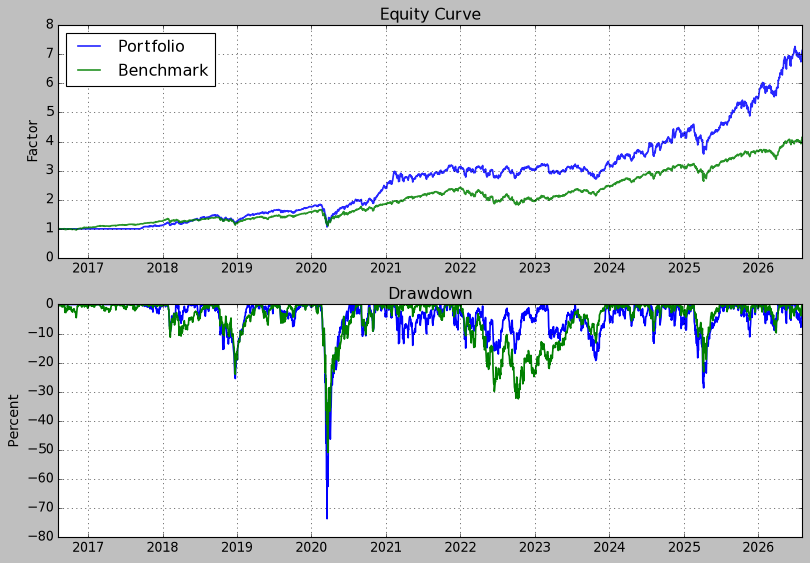

In [17]:
def plot_portfolio_equity(cfg, state, **kwargs):
    fig, axes = plt.subplots(2, 1, figsize=(12,8))

    # We need...
    p_ec = create_portfolio_equity_curve(cfg, state, **kwargs)
    b_ec = create_benchmark_equity_curve(cfg, state, **kwargs)

    p_dd = -create_portfolio_drawdown(cfg, state, **kwargs) * 100
    b_dd = -create_benchmark_drawdown(cfg, state, **kwargs) * 100

    axes[0].set_title('Equity Curve')
    axes[0].plot(p_ec, label='Portfolio', alpha=0.85)
    axes[0].plot(b_ec, label='Benchmark', alpha=0.85)
    axes[0].legend(loc='upper left')
    axes[0].set_ylabel('Factor')

    axes[1].set_title('Drawdown')
    axes[1].plot(p_dd)
    axes[1].plot(b_dd)
    axes[1].set_ylabel('Percent')

    for a in axes:
        a.grid()

kwargs = dict(
    portfolio_builder=CsmPortfolioBuilder
)

plot_portfolio_equity(cfg, state, **kwargs)